# Surface terrestre visible en fonction de l'altitude

On considère la Terre comme une sphère de rayon moyen **R = 6371 km**.

On cherche le pourcentage de surface terrestre visible depuis une altitude $h$.


## 1. Géométrie du problème

La ligne de visée vers l'horizon est tangente à la Terre. Le triangle formé par le centre de la Terre, l'observateur et le point d'horizon est rectangle au point de tangence.

Si $\theta$ est l'angle au centre entre le point situé sous l'observateur et le point d'horizon :

$$\cos(\theta)=\frac{R}{R+h}$$

La surface visible est une calotte sphérique :

$$S_v=2\pi R^2(1-\cos\theta)$$

La surface totale vaut $S_T=4\pi R^2$.

On obtient donc :

$$\boxed{P=100\frac{h}{2(R+h)}}$$


## 2. Normalisation par le rayon terrestre

On pose $x=h/R$. La formule devient :

$$\boxed{P(x)=50\frac{x}{1+x}}$$

Cette forme ne dépend plus du rayon réel de la planète.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

R = 6371.0  # km
x = np.logspace(-3, 4, 1000)  # x = h/R
P = 50 * x / (1 + x)

h_geo = 35786.0
x_geo = h_geo / R
P_geo = 50 * x_geo / (1 + x_geo)

print(f"R = {R:.0f} km")
print(f"Géostationnaire : h/R = {x_geo:.3f}")
print(f"Surface visible : {P_geo:.2f} %")

R = 6371 km
Géostationnaire : h/R = 5.617
Surface visible : 42.44 %


## 3. Graphique à axes linéaires

La courbe est croissante et concave : les premiers kilomètres d'altitude augmentent rapidement la fraction visible, puis le gain diminue progressivement.

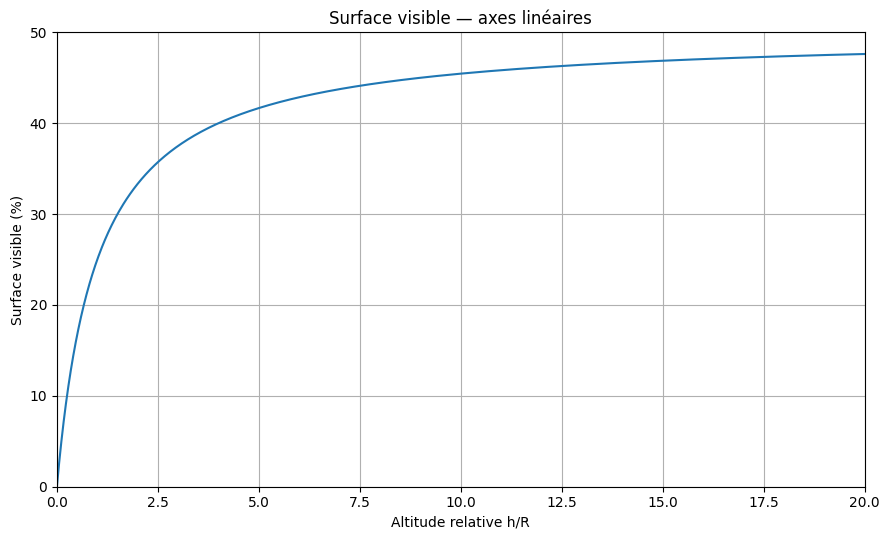

In [2]:
plt.figure(figsize=(9, 5.5))
plt.plot(x, P)
plt.xlabel("Altitude relative h/R")
plt.ylabel("Surface visible (%)")
plt.title("Surface visible — axes linéaires")
plt.xlim(0, 20)
plt.ylim(0, 50)
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Graphique semi-logarithmique

Ici seul l'axe $X$ est logarithmique. Chaque intervalle horizontal représente un facteur 10 sur $h/R$.

La courbe prend alors une apparence de **S**. Trois régimes apparaissent :

- $x\ll1$ : $P\approx50x$ ;
- $x=1$ : $P=25\%$ ;
- $x\gg1$ : $P\approx50\%$.

La forme en S est donc liée au choix de l'échelle logarithmique.

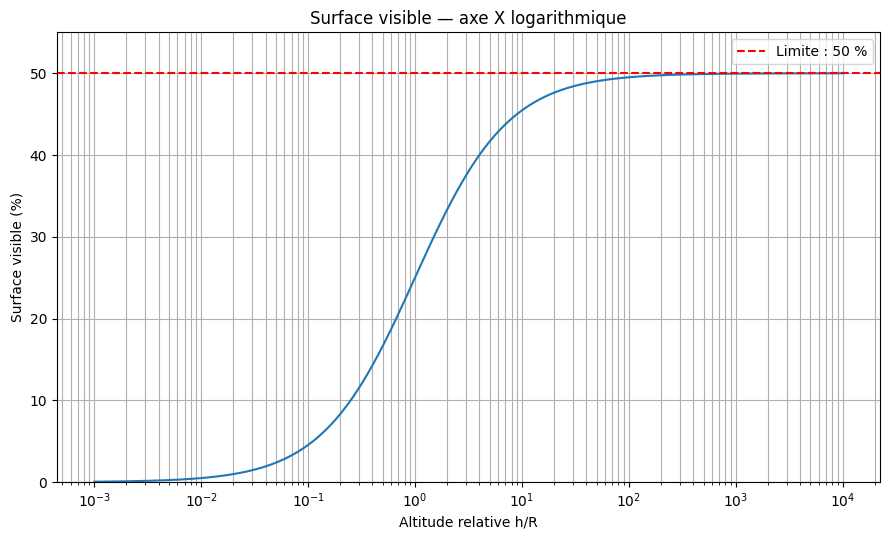

In [6]:
plt.figure(figsize=(9, 5.5))
plt.plot(x, P)
plt.xscale("log")
plt.xlabel("Altitude relative h/R")
plt.ylabel("Surface visible (%)")
plt.title("Surface visible — axe X logarithmique")
plt.ylim(0, 55)
plt.axhline(50, linestyle="--", color='red', label="Limite : 50 %")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Graphique log-log

Les deux axes sont logarithmiques. À faible altitude, $P\approx50x$, donc $P\propto x$ : une loi de puissance apparaît comme une droite en coordonnées log-log.

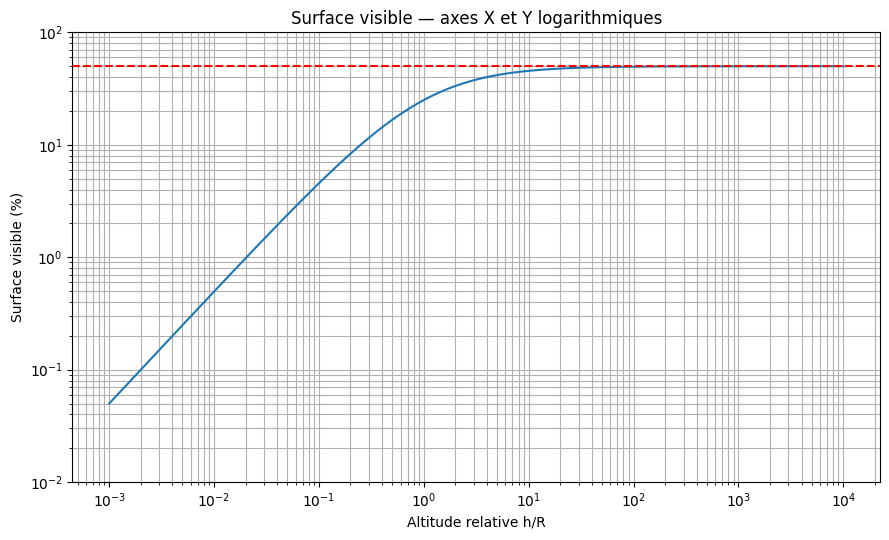

In [16]:
plt.figure(figsize=(9, 5.5))
plt.plot(x, P)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Altitude relative h/R")
plt.ylabel("Surface visible (%)")
plt.axhline(50, linestyle="--", color='red', label="Limite : 50 %")
plt.ylim(0.01, 100)
plt.title("Surface visible — axes X et Y logarithmiques")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

## 6. Propriété remarquable

La fonction vérifie :

$$P(x)+P(1/x)=50\%$$

Par exemple, $P(0.1)\approx4.545\%$ tandis que $P(10)\approx45.455\%$.

Les deux valeurs sont complémentaires à 50 %. Le point $x=1$, soit $h=R$, donne exactement **25 %**.

## 7. Orbite géostationnaire

Pour $h=35786$ km et $R=6371$ km :

$$h/R\approx5.62$$

d'où :

$$P\approx42.4\%$$

Un observateur à cette altitude voit donc environ **42,4 % de la surface terrestre** simultanément.

Enfin :

$$\lim_{h\to\infty}P=50\%$$

La limite de 50 % correspond à un hémisphère.

Si tu es exactement sur la surface mathématique de la Terre, alors :

$$ h=0 $$

et notre formule donne :

$$ P=50\frac{h/R}{1+h/R}=0 $$

Donc 0 % de surface terrestre au sens strict : tu ne vois que le point de contact avec la sphère.

Mais dans la réalité, tes yeux sont à environ 1,7 m au-dessus du sol. Et là, le résultat devient très intéressant.

Avec :

$$ R=6\,371\,000\ {\rm m},\qquad h=1,7\ {\rm m} $$

on obtient :

$$ P=50\frac{1,7}{6\,371\,000+1,7} $$

soit environ :

$$ \boxed{P\approx0,0000133\%} $$

Cela paraît minuscule, mais la Terre est énorme. La surface visible est environ :

$$ S_v \approx 2\pi Rh $$

donc :

$$ S_v\approx2\pi\times6\,371\,000\times1,7 $$ $$ \boxed{S_v\approx68\,000\,000\ {\rm m^2}} $$

soit environ :

$$ \boxed{68\ {\rm km^2}} $$
Et c'est là que ça devient intuitif

À hauteur des yeux de 1,7 m, ton horizon est à environ :

$$ d\simeq\sqrt{2Rh} $$ $$ d\simeq4,65\ {\rm km} $$

Donc tu peux voir jusqu'à environ 4,6 km à l'horizon, et la calotte terrestre correspondante fait environ 68 km².

Autrement dit :

À hauteur d'homme, tu vois une toute petite fraction de la Terre — environ 68 km² — mais cela représente déjà une zone de plusieurs kilomètres autour de toi.

Et cela explique aussi pourquoi notre courbe, près de \(h/R=0\), est pratiquement une droite :

$$ P\simeq50\frac{h}{R} $$

La surface visible est alors approximativement proportionnelle à ta hauteur au-dessus du sol.

😂 Exactement ! À 1 cm de hauteur, l'horizon serait beaucoup moins ambitieux.

Pour donner une idée, avec \(h=1\) cm :

$$ d\simeq\sqrt{2Rh} $$

donne seulement :

$$ \boxed{d\approx357\ \text{m}} $$

et la surface visible :

$$ S_v\simeq2\pi Rh $$

soit :

$$ \boxed{S_v\approx0,40\ \text{km}^2} $$

Donc notre pauvre escargot ne voit qu'une petite zone d'environ 400 000 m² autour de lui.

Et à 1 mm :

$$ d\approx113\ \text{m} $$

et seulement environ :

$$ S_v\approx0,04\ \text{km}^2 $$

Soit 40 000 m².

L'escargot pourrait néanmoins se consoler : à son échelle, son horizon est relativement vaste. 🐌

Et il y a une conséquence amusante : si on prend un animal de hauteur \(h\), la distance à l'horizon varie comme

$$ \boxed{d\propto\sqrt{h}} $$

alors que la surface visible varie comme

$$ \boxed{S\propto h} $$

près de la surface. Donc doubler la hauteur ne double pas la distance à l'horizon, mais double approximativement la surface visible.